# Módulo II: Demodulación de señal APT

`Grupo`: D1

`Estudiantes`:Agustin Ferreira - Luca Guarino - Juan Ignacio Sorondo

Ahora que Ud. conoce en qué consiste el sistema de transmisión APT de los satélites NOAA, el objetivo de este segundo módulo es demodular una señal previamente registrada con el SDR, y si todo sale bien, obtener una primera imagen.

Como insumo para decodificar una primera imagen, Ud. va a contar con una grabación IQ (fase y cuadratura) que fue recibida con un SDR conectado a una antena adecuada. La captura fue registrada con una tasa de 96 000 muestras por segundo, con frecuencia central la correspondiente al satélite.

In [1]:
# IMPORTS PARA TODO EL NOTEBOOK

import numpy as np
from scipy.io import wavfile
import scipy.signal as signal
import matplotlib.pyplot as plt
from scipy import signal
from PIL import Image
from matplotlib.pyplot import imshow


## 0. Levantar datos de grabación de señal capturada con SDR

Durante este notebook trabajaremos con dos grabaciones de señales capturadas en 2019. Ambas consisten en la misma señal de 4 minutos aprox, solo que una de ellas fue acotada a 64 segundos para poder trabajar en una primera instancia de forma más rápida. Las grabaciones se encuentran en la carpeta "Grabaciones" en el EVA

Comience a trabajar con la versión reducida y luego de armar todo el sistema de recepción repetir con la captura completa.

El siguiente código sirve para levantar las muestras I y Q del archivo.

In [2]:
from google.colab import files
uploaded = files.upload()


Saving satelites64s.npy to satelites64s.npy


In [3]:
# Frecuencia de muestro del archivo
fs = 96000

# Levantar datos
filename =  'satelites64s.npy'
f = np.load(filename)

i = f.real
q = f.imag


## 1. Analisís de la señal recibida



Comience por observar en tiempo y frecuencia la señal APT modulada.

- ¿Cual es el ancho de banda esperado de la señal capturada?
- ¿Qué ancho de banda se observa?

In [4]:
# Funciones auxiliares

def plot_frec(x,fs,fmax,m):
  puntos = int(fmax/fs*m)
  lx = len(x)
  nt = (lx + m - 1)//m
  xp = np.append(x,np.zeros(-lx+nt*m))
  xmw = np.reshape( xp, (m,nt), order='F')
  xmf = np.fft.fft(xmw,len(xmw),axis=0)/m
  xf = np.linspace(0, int(fs/2.0), int(m/2))
  plt.figure(figsize=(10,6))
  plt.title('Análisis en frecuencia',loc='center')
  plt.yscale("log")
  plt.plot(xf[0:puntos],np.abs(xmf[0:int(m/2),0:int(lx/m-1)]).mean(1)[0:puntos])
  plt.show()

def filtro_pasabajo(x,f_corte,fs):
	taps = signal.firwin(151,f_corte,nyq=fs/2.0)
	filtered_x = signal.lfilter(taps, 1.0, x)
	return(filtered_x)

def filtro_pasabanda(x,f_corte1,f_corte2,fs):
  taps = signal.firwin(151, [f_corte1, f_corte2], pass_zero=False,nyq=fs/2.0)
  filtered_x = signal.lfilter(taps, 1.0, x)
  return(filtered_x)



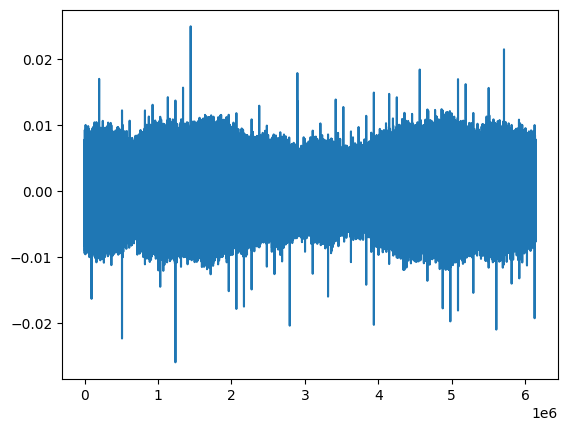

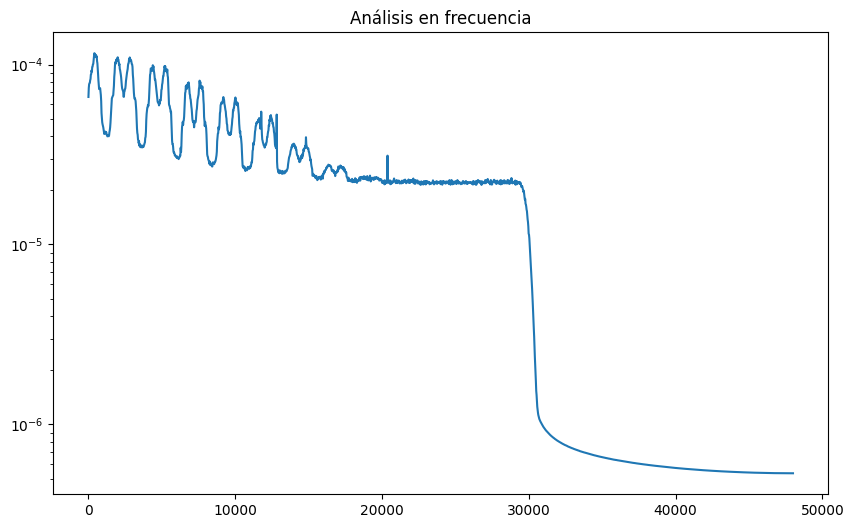

In [5]:
# Analisis en Tiempo
plt.plot(i)
plt.show()
# Analisis en Frecuencia
plot_frec(i,fs,50000,4096)

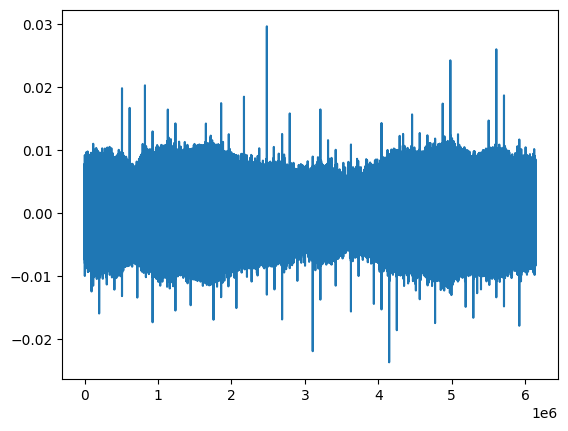

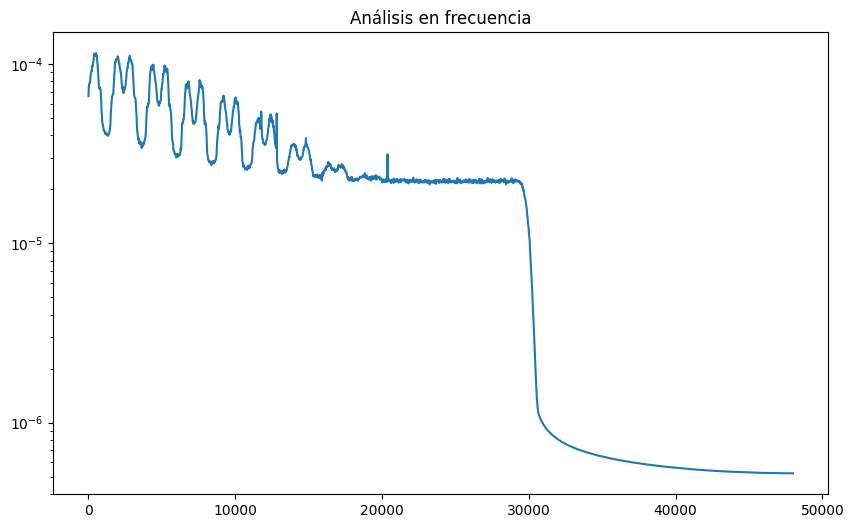

In [6]:
# Analisis en Tiempo
plt.plot(q)
plt.show()

# Analisis en Frecuencia
plot_frec(q,fs,50000,4096)


Se espera un ancho de banda de señal FM, en el mayor de los casos, aproximadamente 50kHz, esto se debe a que el ancho de banda antes de modular en FM se multiplica en un rango de (2~10).
 El ancho de banda observado es de aproximadamente 30kHz, parece haber un filtro pasabajo involucrado.

## 2. Demodulación FM


El primer paso para demodular la señal APT es realizar una demodulación FM. Para esto utilice el demodulador hecho en el parcial y analice nuevamente en tiempo y frecuencia la señal.

- ¿Qué ancho de banda se esperaría que tenga la señal?
- ¿Qué ancho de banda se tiene?



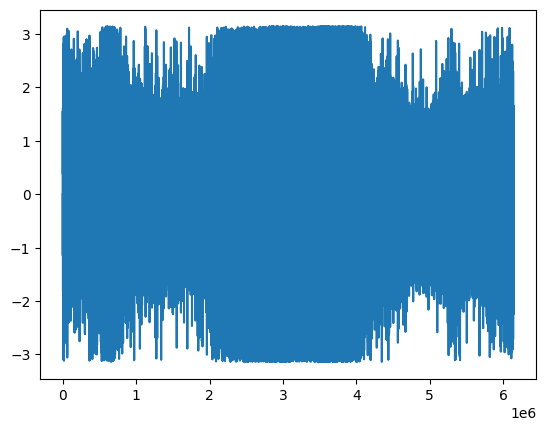

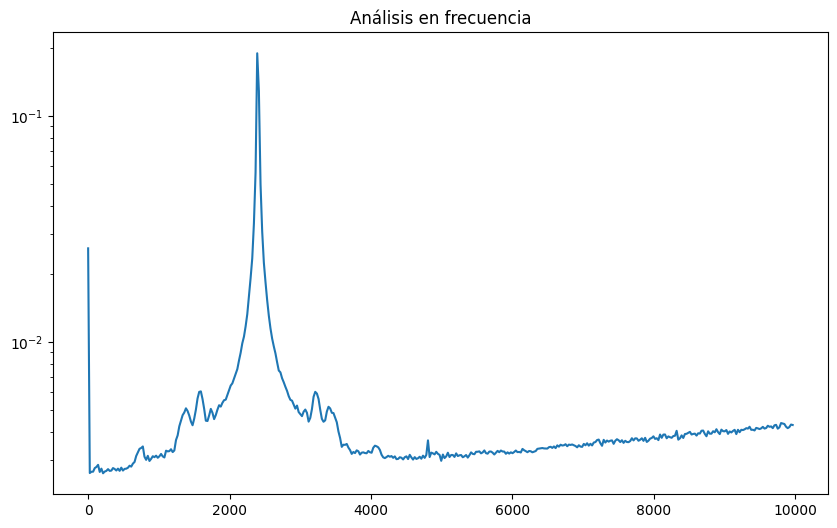

In [ ]:
# Demodular FM
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt


fi = np.arctan2(q,i)             #) Funcion artan2, la explicacion respecto a su uso se encuentra en el informe, esta recibe los vectores que teoricamente al dividirlos son iguales a la tangente, por este motivo esd que se busca su inversa, el arctan, para obtener fi
uw =  np.unwrap(fi)              #) Funcion de NumPy Unwrap, la explicacion respecto a su uso se encuentra en el informe, esta recibe el arctan2 de q e i.

senial = np.zeros(len(uw))       #) Se crea un vector de ceros del tamaño de nuestra señal

for k in range(1, len(uw)):      #) Se crea un bucle for que recorre el largo de nuestra señal sin contar su primer elemento(O) (en la teoria esto es la derivada)
  senial[k] = uw[k]-uw[k-1]      #) Recorre nuestro vector haciendo dicha diferencia.

# Analisis en tiempo
plt.plot(senial)
plt.show()

# Analisis en Frecuencia
plot_frec(senial,fs,10000,4096) #) Graficamos para observar


Teoricamente la señal demodulada se trata de una señal AM, por lo tanto el ancho de banda esperado es de 4480 Hz aproximadamente,el cual concuerda con lo observado en la grafica.

## 3. Demodulación AM

Luego de demodular la señal en FM, hay que demodularla en AM. Para esto, implementar un demodulador AM utilizando las técnicas tratadas en el parcial. Para esto recordar la siguiente relación trigonometrica:

$$\cos^2(\theta) = \frac{1 + \cos(2\theta)}{2}$$

Finalmente analizar en tiempo y frecuencia.

- ¿Que ancho de banda se espera que tenga la señal?
- ¿Que ancho de banda se observa?


<ipython-input-84-387ff1295e39>:18: DeprecationWarning: Keyword argument 'nyq' is deprecated in favour of 'fs' and will be removed in SciPy 1.12.0.
  taps = signal.firwin(151,f_corte,nyq=fs/2.0)


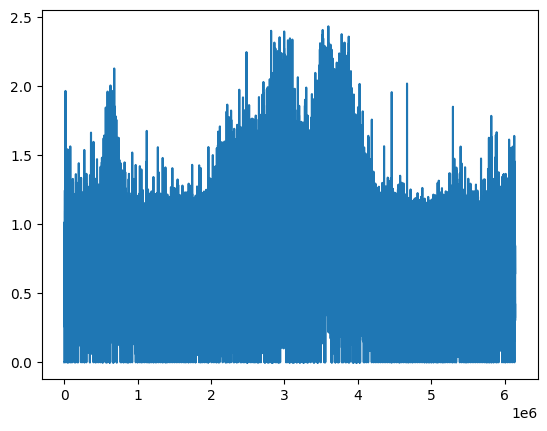

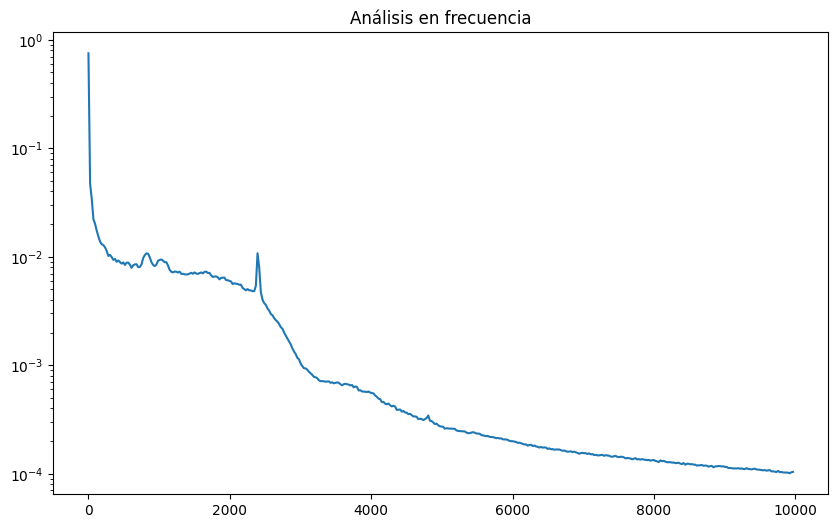

In [ ]:
# Demodular AM

t=np.array(len(senial))                      #) Hacemos un array del largo de nuestra señal

senialapt = senial**2                        #) Para respetar el Teorema del muestreo multiplicamos por 2 nuestra señal.

data_f = filtro_pasabajo(senialapt,2520,fs)  #) La pasamos por un filtro pasabajo a 2400 + 5% de margen

# for k in range(len(data_f)):               #) Como data_f no puede ser negativa debido a la raiz hacemos un bucle for que recoora data_f y intercambia los valores negativos por 0
#   if  (data_f[k]<0):
#     data_f[k]=0

#) Como este bucle consume muchos recursosse utiliza
data_f[data_f < 0] = 0

datafinal= np.sqrt(data_f*2)                 #) Como en la ecuacion esta dividido entre 2 lo multiplicamos para obtener la señal deseada

# Analisis en tiempo
plt.plot(datafinal)
plt.show()

# Analisis en frecuencia
plot_frec(datafinal,fs,10000,4096)

Se espera el ancho de banda de una señal APT, de aproximadamente 2080 Hz, lo cual concuerda con lo observado en la grafica

## 4. Resampleo

Recordando el taller anterior, la imagen satlital se envia de forma serializada. Esto es, la imagen que es de 2 dimensiones, se transforma en 1D concatenando las filas una tras otra. También recordamos que cada linea consiste en 2080 píxeles, y se envía en 0.5 segundos.

En esta sección y la siguiente buscaremos pasar nuestra señal 1D, a una matriz 2D que corresponda a la imagen. Las siguientes preguntas sirven como guía para este objetivo.

- ¿Cuánto tiempo demora en enviarse un único píxel?
- ¿Cuál es la frecuencia de muestro con la que estamos trabajando?
- Dado la respuesta de las dos preguntas anterioriores, ¿cuántas muestras presenta la señal por píxel?
- ¿Qué frecuencia de muestreo es necesaria, para que nuestra señal tenga una muestra por píxel?
- ¿Cómo podemos hacer para cambiar a esa frecuencia de muestreo?

Para responder esta última pregunta, averiguar sobre la función "scipy.signal.resample_poly".

Implementar el resampleo y observar el resultado en tiempo y frecuencia.



Utilizando reglas de tres llegamos a que si 2080 pixeles se envian en 0,5 segundos, un pixel se envia en 0,00024 s. La frecuencia de muestreo es 96000 por segundo, por lo tanto, teniendo en cuenta que un pixel demora en enviarse 1/4160, las muestras por pixel son 300/13. La frecuencia necesaria es de 4160 muestras. la funcion resample nos hace este trabajo, hay que procurar poner los numeros adecuados para que tome un valor entero.


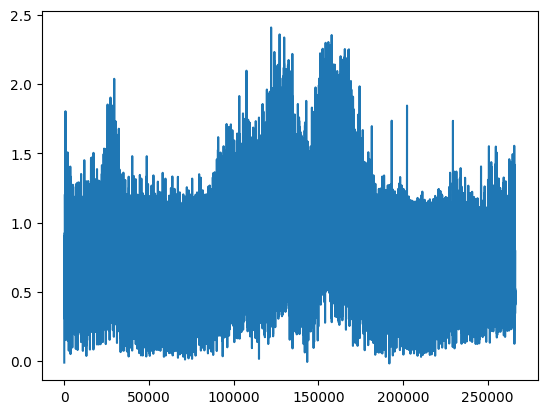

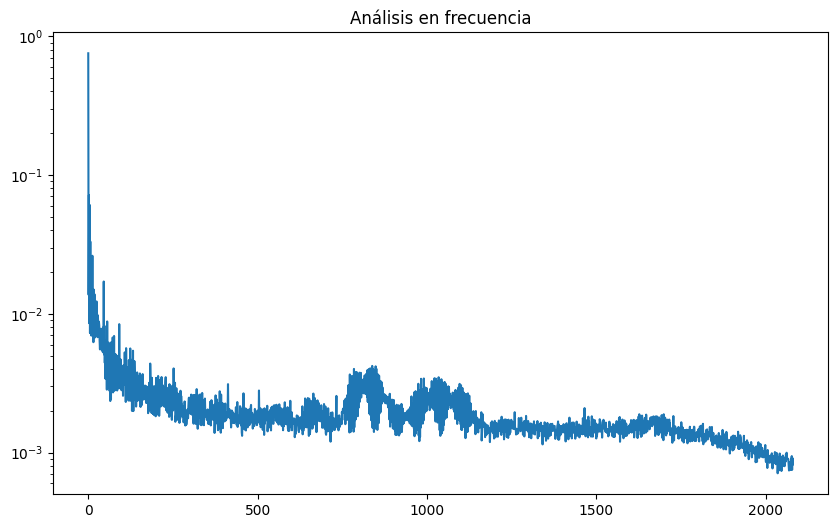

In [ ]:
# Resampleo
import scipy.io
yre = scipy.signal.resample_poly(datafinal,13,300)      #) Aplicacion de la funcion
fs=4160

# Analisis en tiempo
plt.plot(yre)
plt.show()

# Analisis en frecuencia
plot_frec(yre,fs,10000,4096)

## 6.Armado de Matriz

Ahora tenemos una señal APT donde cada muestra corresponde a un píxel. Sin embargo sigue siendo una señal 1D. Para poder visualizar nuestra imagen debe ser 2D. Las siguientes preguntas sirven como guía para lograr esto.

- ¿Si tenemos 64 segundos de señal, cuántas líneas vamos a tener?
- ¿Cuántos píxeles tiene una línea?
- Apartir de estas dos preguntas, ¿Qué tamaño debe tener la matriz a recuperar y cuantos píxeles va a tener?
- ¿Cuántas muestras tenemos?

Transformar la señal 1D en una señal 2D con las dimensiones adecuadas. Para esto investigar cómo se utiliza la función "np.reshape".

Chequear que las dimensiones de la imagen sean las correctas, y graficar en el tiempo distintas líneas de la imagen. Analizar el resultado.


Como cada linea demora 0,5 en enviarse, en 64 segundos vamos a tener 128 lineas, tras resamplear tenemos que cada linea tiene 2080 pixeles. La matriz sera 128x2080, y los pixeles que tendra sera el producto de estos.

In [ ]:
# Reshape
rp = np.reshape(yre, ( 128,2080))

## 7. Visualización de la imagen

Ahora que cuenta con una matriz, es hora de visualizarla. Se da un código de ejemplo donde se muestra como visualizar una matriz de 2 dimensiones donde cada pixel es un numero random entre 0 y 255. Repetir esto para visualizar la imagen satelital demodulada.

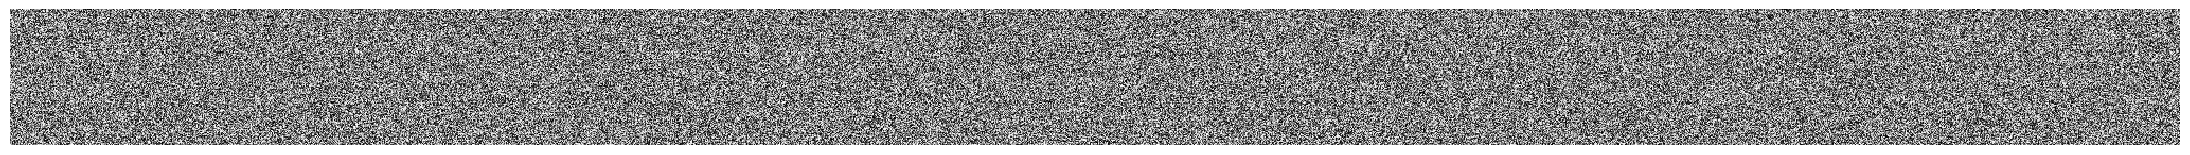

In [ ]:
# Visualizar imagen random
matriz_random = 255 * np.random.random((128,2048))
img = Image.fromarray(matriz_random)
plt.figure(figsize=(28,12))
plt.axis('off')
imshow(img,interpolation='none')
plt.show()

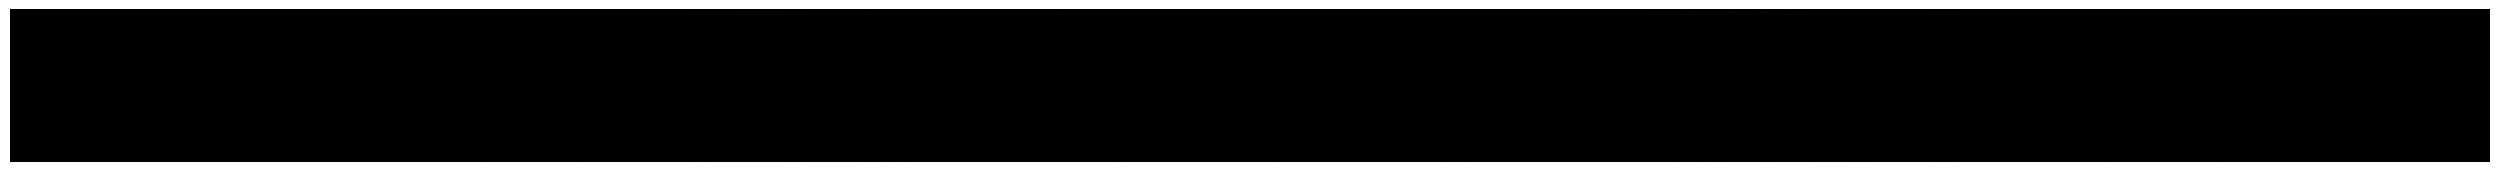

In [ ]:
# Repetir con imagen satelital

img = Image.fromarray(rp)
plt.figure(figsize=(32,12))
plt.axis('off')
imshow(img,interpolation='none')
plt.show()

## 8. Reescalado de la matriz

La imagen anterior no es muy esperanzadora. Para entender porque se observa todo negro, debemos entender qué valores esta tomando nuestra señal actualmente, qué valores deberia tomar, y por qué ocurre esto.

- ¿Qué valor máximo y mínimo tiene la señal?
- ¿Qué valor corresponde a negro en la imagen, y que valor corresponde a blanco en la imagen?
- Pensar posibles causas que puedan provocar esto.
- ¿Qué estrategia sencilla se le ocurre para que el valor máximo de nuestra señal corresponda a negro, y el valor mínimo corresponda a blanco? Implementarla y observar los nuevos valores máximos y mínimos de la señal.


Teoricamente el valor maximo es 255 (blanco) y el minimo es el 0 (negro), pero nuestra señal tiene otros maximos y minimos:

In [ ]:
# Reescalar imagen
print(np.amax(rp))                             #) Vemos el minimo y maximo de la señal recibida, estos valores son aproximadamente -0.017 y 2,41, muy alejados de el 0 y el 255 respectivamente
print(np.amin(rp))                             #) El primer paso a solucionar es que los valores sean enteramente positivos, y que se el minimo sea 0.

normalizando= rp-np.amin(rp)                   #) A la señal recibida se le le resta el minimo, que este al ser negativo camiba su signo.

rpp=normalizando*(255/np.amax(normalizando))   #) Teniendo el minimo en 0 ya podemos multiplicar los valores por la relacion entre 255, que es nuestro valor buscado, y el maximo de la senial pre-normalizada

print(np.amax(rpp))
print(np.amin(rpp))                            #) Corroboramos el minimo y el maximo.


2.407635908098205
-0.017212627456512756
255.0
0.0


## 9. Visualización de la imagen 2.0

Utilizando el código de la parte 7 y con la imagen normalizada, volver a visualizar la imagen. Comentar que se observa

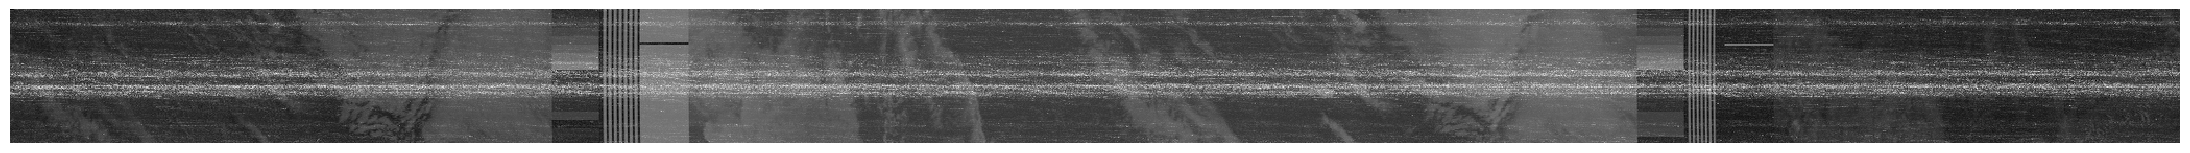

In [ ]:
img = Image.fromarray(rpp)
plt.figure(figsize=(28,12))
plt.axis('off')
imshow(img,interpolation='none')
plt.show()

Se observa la imagen satelital, se pueden observar lo que parecen ser nubes y una linea blanca horizontal que se puede interpretar como ruido, a su vez se observa las partes de cada linea, sync, telemetry,etc.

Ahora que tenemos el sistema de recepción andando, repetir para la señal completa.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving apt_demod.npy to apt_demod (1).npy


In [ ]:
# Levantar datos
filename =  'apt_demod.npy'
apt = np.load(filename)

Como indica el nombre del archivo la senial ya se encuentra demodulada y resampleada.

In [ ]:
print(len(apt)/4160)     #) Dividimos el largo de la señal por la tasa de muestreo despues de resamplear para obtener los segundos de la grabacion

747.0


255.0
0.0


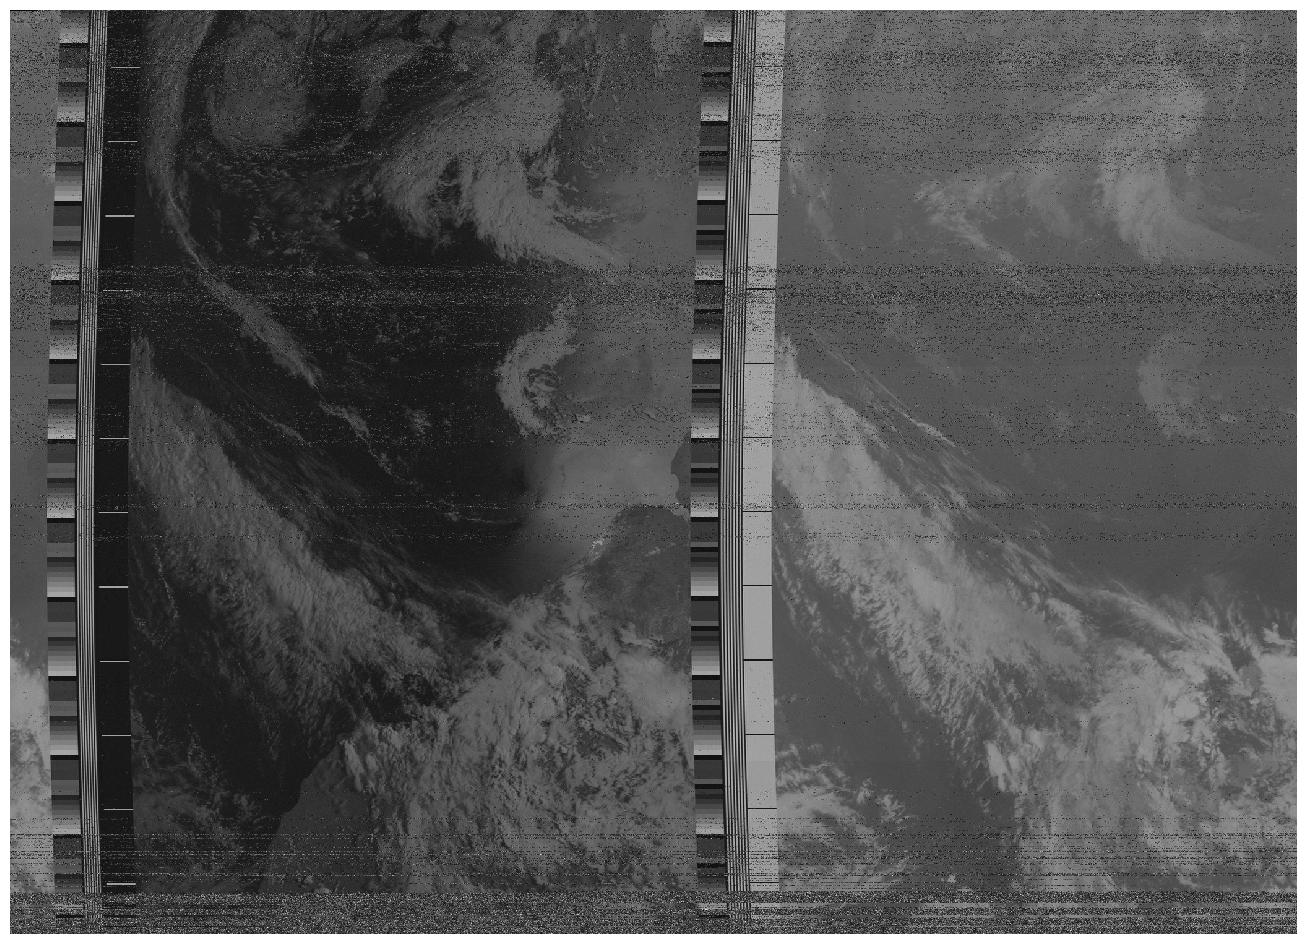

In [ ]:
# Reshape
rshapt = np.reshape(apt, ( 747*2,2080))            #) Para saber las cantidad de lineas divido el largo de nuestra data entre 4160 Hz, que es la tasa de muestreo despues de resamplear y multiplico x2 ya que cada linea se manda en 0.5 s.

print(np.amax(rshapt))
print(np.amin(rshapt))                             #) Corroboramos el minimo y el maximo. No hace falta normalizar

img = Image.fromarray(rshapt)
plt.figure(figsize=(28,12))
plt.axis('off')
imshow(img,interpolation='none')
plt.show()


podemos notar la imagen satelital de Uruguay dada vuelta.
Utilizando matplot podemos rotar la imagen

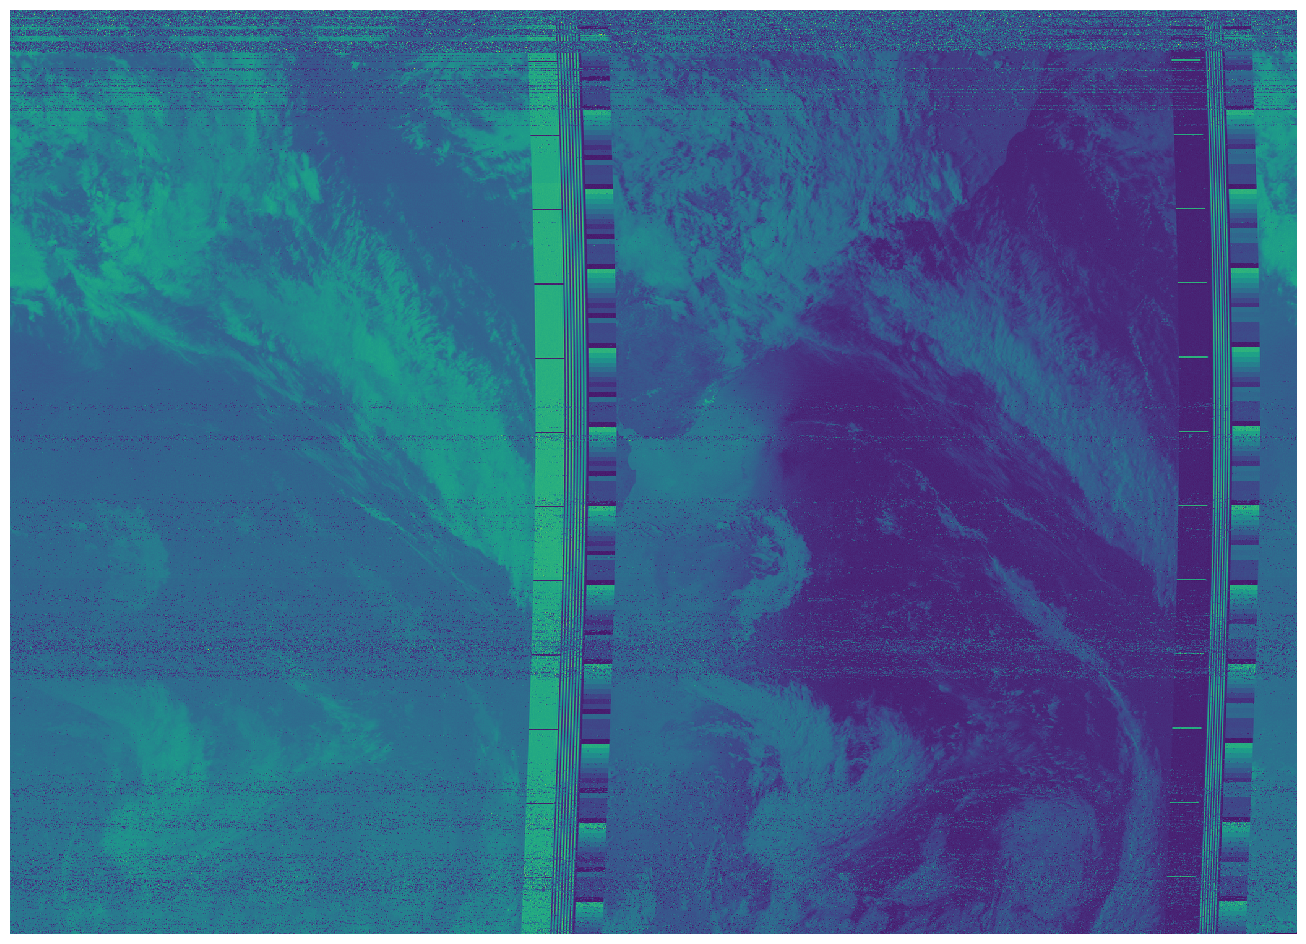

In [ ]:
import matplotlib.image as mpimg

# Rotar la imagen
img_rotada = np.rot90(rshapt, k=2)           #) Rota la imagen 90 grados 2 veces(k=2) para obtener 180 grados

# Mostrar la imagen rotada
plt.figure(figsize=(28,12))
plt.axis('off')
plt.imshow(img_rotada, interpolation='none')
plt.show()


Pudimos rotar la imagen, pero observamos colores que no deberian de estar, esto se debe a que no especificamos sobre que mapa estamos trabajando y la biblioteca matplotlib utiliza un mapa por defecto, si especificamos que seguimos trabajando con escala de grises vemos lo siguiente

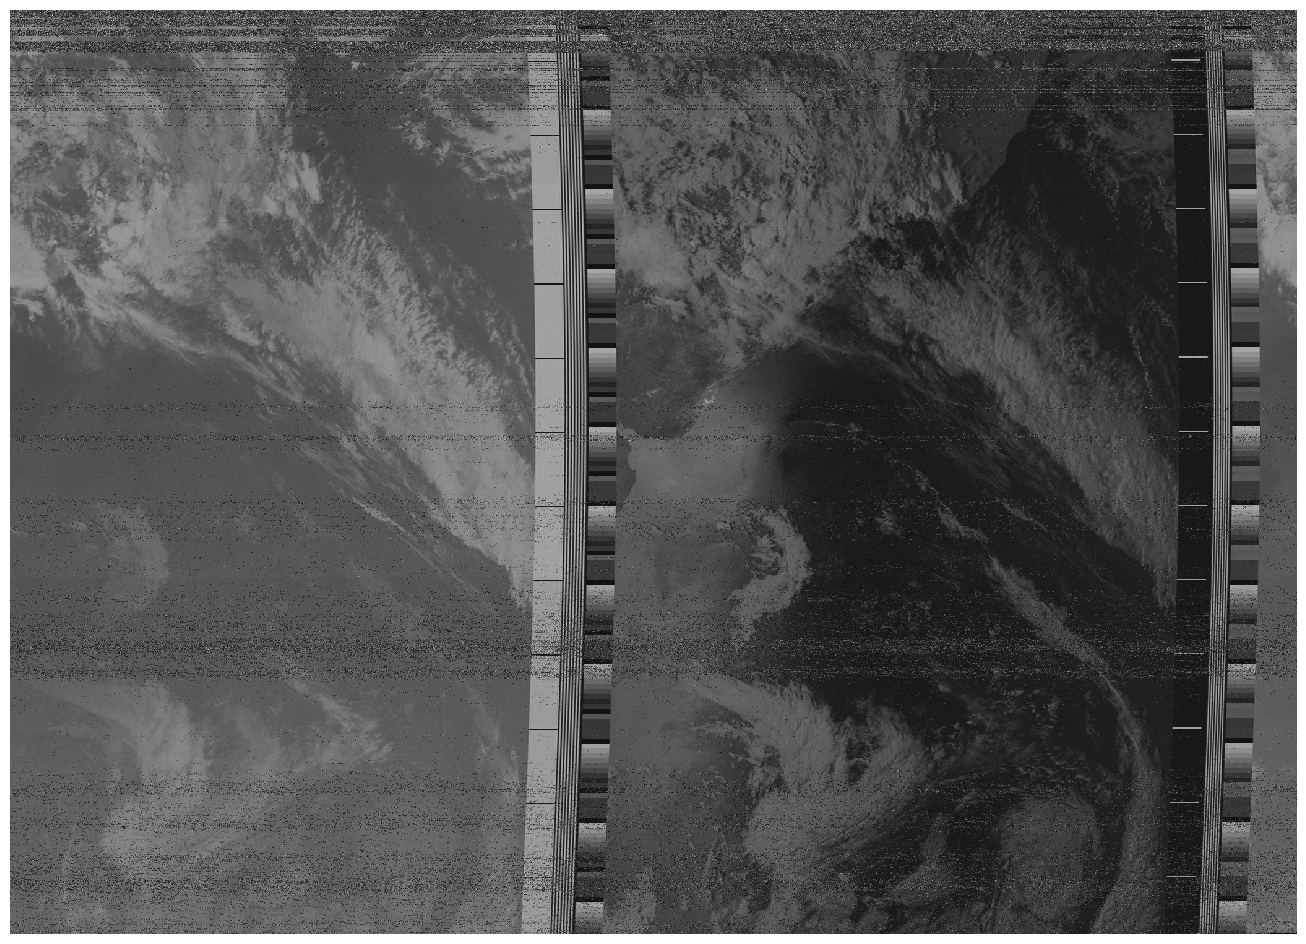

In [ ]:
# Mostrar la imagen rotada y escala de grises
plt.figure(figsize=(28,12))
plt.axis('off')
plt.imshow(img_rotada, cmap='gray', interpolation='none')
plt.show()


Llegamos a la imagen del Rio de La Plata, con el norte alineado. Sigue estando en escala de grises y se observa "ruido"






























## Entregable

 - Ud. deberá subir el notebook al EVA con el código para la demodulación y visualización de la imagen, coloque también en el notebook todas las gráficas importantes para poder explicar el proceso de demodulación (tanto en tiempo como en frecuencia), recuerde que puede agregar celdas de texto para acompañar el código y facilitar la lectura.